# Fabriekscapaciteit versus doorvoer: tweedimensionale portefeuilleanalyse met PROC SGPLOT

## Samenvatting

Een productieportefeuille in de discrete industrie heeft twee getallen die voor elke productielijn tegelijk van belang zijn: **hoeveel machinecapaciteit ze verbruikt** en **hoeveel goede output ze werkelijk levert**. Een eendimensionale staafgrafiek kan er maar één van tonen. Dit notebook visualiseert beide samen met `PROC SGPLOT`, met een **bel-diagram (bubble plot)** als kernweergave — elke lijn wordt gepositioneerd op capaciteit (x) en doorvoer (y), waarbij de belgrootte het productiviteitspercentage (eenheden per machine-uur) weergeeft. Lijnen die rechtsonder liggen (veel capaciteit, weinig output) zijn capaciteitsverslinders; lijnen die linksboven liggen met een grote bel hebben een hoog rendement. Een gegroepeerde staafweergave splitst vervolgens de doorvoer per fabriek uit, en een productiviteitsrangschikking bevestigt de kloof.

Op basis van de werkelijk uitgevoerde output (acht productielijnen over drie fabrieken, 100 runs op dienstniveau geaggregeerd tot 24 cellen per lijn-en-fabriek) blijkt **Gieten** de duidelijkste capaciteitsverslinder van de portefeuille (14,3 goede eenheden per machine-uur — het verbruikt 10,1% van de totale capaciteit maar levert slechts 3,2% van de goede eenheden) terwijl **Verpakking** de opvallende lijn met hoog rendement is (119,2 eenheden per uur — 9,1% van de capaciteit levert 23,8% van de output). Per fabriek draait **Stuttgart** het heetst met 49,9 eenheden/uur en **Monterrey** het koelst met 41,6.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | Synthetische productieruns op dienstniveau over 8 productielijnen, 3 fabrieken en 3 diensten — geplande machine-uren, draaiuren, uitval, bruto-/afkeur-/goede eenheden (begrensd op 100 waarnemingen in de niet-gelicentieerde modus) | 100 |
| WORK.LINE_CAPACITY | Geaggregeerde samenvatting per productielijn en per fabriek: totale capaciteitsuren (x), geproduceerde goede eenheden (y), en acceptatiepercentage (yield %) | 24 |

*Alle data is synthetisch en inline in het notebook gegenereerd met een vaste seed — geen externe bestanden, geen netwerk.*

# Analyse van fabriekscapaciteit versus doorvoer

**Domein:** Discrete industrie — operations / bedrijfskunde

**Procedure:** `PROC SGPLOT` (ODS Statistical Graphics)

Een conventionele staafgrafiek toont één respons per categorie. Om een productieportefeuille op **twee** numerieke dimensies tegelijk te vergelijken — *hoeveel capaciteit elke productielijn verbruikt* versus *hoeveel output ze werkelijk levert* — hebben we een grafiek nodig die beide op hetzelfde canvas plaatst. De `BUBBLE`-instructie van `PROC SGPLOT` doet precies dat: ze positioneert elke lijn op capaciteit (x) en goede eenheden (y) en laat een derde maatstaf, het productiviteitspercentage, de belgrootte bepalen. Een lijn die ver rechts maar laag ligt, is een capaciteitsverslinder; een lijn die hoog en links ligt met een dikke bel is een lijn met hoog rendement die het beschermen waard is. Dit notebook bouwt een realistische synthetische productiedataset en stuurt SGPLOT aan via een bel-diagram, een per-fabriek gegroepeerde staafgrafiek, een analyse van één fabriek, en een naast-elkaar geclusterde fabrieksvergelijking.

> **Een opmerking over PROC GAREABAR.** De klassieke SAS/GRAPH-manier om twee dimensies per *staaf* te coderen is `PROC GAREABAR` (een alleen-ActiveX vlak-staafgrafiek waarbij staafbreedte de ene variabele codeert en hoogte de andere). GAREABAR is **nog niet geïmplementeerd in deze Jenner-build** — het gat wordt bijgehouden door de gebankte test `tests/400996_nb_gareabar_unimplemented`. Dit notebook bereikt hetzelfde analytische doel met de volledig ondersteunde `PROC SGPLOT`, waarvan de bel- en gegroepeerde-staafweergaven exact hetzelfde capaciteit-versus-doorvoerverhaal overbrengen.

## 1. Genereer synthetische productiedata

We simuleren zes weken productieruns op dienstniveau voor een discreet productienetwerk met drie fabrieken. Elke productielijn heeft een basis-cyclustijd en afkeurpercentage; de doorvoer wordt aangestuurd door geplande machine-uren, lijnspecifieke efficiëntie en willekeurige uitval. `call streaminit` legt de seed vast zodat het notebook volledig reproduceerbaar is — geen externe bestanden, geen netwerk.

In [1]:
/* --------------------------------------------------------
   Synthetische productieruns op dienstniveau
   8 productielijnen x 3 fabrieken x 3 diensten x ~10 dagen
   breedtevariabele = geplande machine-uren (capaciteit)
   respons          = geproduceerde goede eenheden (doorvoer)
   -------------------------------------------------------- */
GEGEVENS work.production_runs;
    CALL streaminit(20260531);
    LENGTE product_line $18 plant $12 shift $8;

    REEKS line_names[8] $18 _temporary_
        ('Stampen'  'Lassen'   'Verspanen' 'Gieten'
         'Spuitgieten' 'Montage'  'Afwerking' 'Verpakking');
    /* nominale eenheden geproduceerd per machine-uur, per lijn */
    REEKS line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* basis-afkeurfractie per lijn */
    REEKS line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    REEKS plant_names[3] $12 _temporary_
        ('Detroit' 'Monterrey' 'Stuttgart');
    /* efficientiefactor per fabriek */
    REEKS plant_eff[3] _temporary_ (1.00 0.92 1.08);
    REEKS shift_names[3] $8 _temporary_ ('Dag' 'Avond' 'Nacht');
    REEKS shift_eff[3] _temporary_ (1.00 0.95 0.88);

    DOE day = 1 TOT 10;
        DOE li = 1 TOT 8;
            DOE pi = 1 TOT 3;
                DOE si = 1 TOT 3;
                    product_line = line_names[li];
                    plant        = plant_names[pi];
                    shift        = shift_names[si];

                    /* geplande machine-uren voor de dienst */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* ongeplande uitval eet in de capaciteit */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* effectief doorvoerpercentage met ruis */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    UITVOER;
                EINDE;
            EINDE;
        EINDE;
    EINDE;
    BEWAREN run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    OPMAAK run_date date9.;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.production_runs(obs=8) noobs label;
    label run_date="Productiedatum" product_line="Productielijn" plant="Fabriek" shift="Dienst"
          sched_hours="Geplande machine-uren" run_hours="Effectieve draaiuren"
          downtime_hours="Uitvaluren" gross_units="Bruto-eenheden"
          scrap_units="Afkeur-eenheden" good_units="Goede eenheden";
    TITEL "Steekproef van synthetische productieruns op dienstniveau";
UITVOEREN;
TITEL;


                               Steekproef van synthetische productieruns op dienstniveau                                

Productiedatum  Productielijn    Fabriek  Dienst  Geplande machine-uren  Effectieve draaiuren  Uitvaluren  Bruto-eenheden  Afkeur-eenheden  Goede eenheden
     05JAN2026  Stampen        Detroit    Dag                       7.8                   6.7         1.1             306               14             292
     05JAN2026  Stampen        Detroit    Avond                     6.8                   6.5         0.3             259               12             247
     05JAN2026  Stampen        Detroit    Nacht                       8                   7.6         0.4             269               11             258
     05JAN2026  Stampen        Monterrey  Dag                       7.9                   6.8         1.1             283               12             271
     05JAN2026  Stampen        Monterrey  Avond                     7.5                   6.9         0


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.16 seconds
  cpu   0.16 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. Aggregeer naar lijn-en-fabrieksniveau

De grafieken vergelijken één punt per categorie, dus rollen we het detail op dienstniveau op tot een samenvatting per productielijn en per fabriek. `total_capacity` (som van geplande machine-uren) wordt de **x**-dimensie, `good_units` (som van geaccepteerde output) de **y**-dimensie, en `units_per_hr` (goede eenheden ÷ capaciteitsuren) het productiviteitspercentage dat de belgrootte bepaalt. We behouden `plant` zodat het later als groeperingsvariabele kan dienen. We bouwen ook een lijn-niveau-oprol (over alle fabrieken heen) voor het portefeuille-bel-diagram.

In [2]:
/* --------------------------------------------------------
   Roll up naar product_line x plant
   total_capacity -> x (capaciteitsuren)
   good_units     -> y (doorvoer)
   units_per_hr   -> belgrootte (productiviteit)
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.production_runs NOPRINT NWAY;
    KLASSE product_line plant;
    VARIABELE sched_hours good_units scrap_units;
    UITVOER out=work.line_capacity(VERWIJDEREN=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
UITVOEREN;

GEGEVENS work.line_capacity;
    INSTELLEN work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    OPMAAK units_per_hr 6.1 yield_pct 5.1;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=work.line_capacity;
    VOLGENS product_line plant;
UITVOEREN;

/* Lijn-niveau-oprol (over alle drie fabrieken) voor de portefeuilleweergave */
PROCEDURE GEMIDDELDEN GEGEVENS=work.line_capacity NOPRINT NWAY;
    KLASSE product_line;
    VARIABELE total_capacity good_units;
    UITVOER out=work.line_total(VERWIJDEREN=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
UITVOEREN;

GEGEVENS work.line_total;
    INSTELLEN work.line_total;
    units_per_hr = good_units / total_capacity;
    OPMAAK units_per_hr 6.1;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=work.line_total;
    VOLGENS units_per_hr;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.line_total noobs label;
    VARIABELE product_line total_capacity good_units units_per_hr;
    label product_line="Productielijn" total_capacity="Totale capaciteit"
          good_units="Goede eenheden" units_per_hr="Eenheden per uur";
    TITEL "Portefeuillelijnen gerangschikt naar productiviteit (goede eenheden per machine-uur)";
UITVOEREN;
TITEL;


                  Portefeuillelijnen gerangschikt naar productiviteit (goede eenheden per machine-uur)                  

Productielijn  Totale capaciteit  Goede eenheden  Eenheden per uur
Gieten                      73.4            1050              14.3
Lassen                     130.8            3038              23.2
Verspanen                  128.9            3762              29.2
Stampen                    130.7            4713              36.1
Spuitgieten                 66.2            3430              51.8
Montage                     67.3            4289              63.7
Afwerking                   64.6            4927              76.3
Verpakking                  65.9            7855             119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. Open de ODS Graphics-bestemming

`PROC SGPLOT` rendert via ODS Statistical Graphics. We openen een `ODS HTML`-bestemming zodat elke grafiek als afbeelding wordt uitgevoerd, en zetten `ODS GRAPHICS ON`. Er is geen speciaal apparaatstuurprogramma nodig — SGPLOT is apparaatonafhankelijk, in tegenstelling tot de alleen-ActiveX SAS/GRAPH-procedures.

In [3]:
ODS html;
ODS GRAPHICS ON;



NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. Portefeuille-bel-diagram — capaciteit versus doorvoer

De kernweergave: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. Elke productielijn is één bel, gepositioneerd op totale capaciteitsuren (x) en totale goede eenheden (y), waarbij het beloppervlak geschaald is naar het productiviteitspercentage. `DATALABEL=` drukt de lijnnaam naast elke bel af. Dit is de tweedimensionale vergelijking die een fabrieksmanager wil — capaciteitsverslinders vallen **rechtsonder** (veel uren, weinig output, kleine bel); lijnen met hoog rendement stijgen **linksboven** (weinig uren, veel output, grote bel).

                                   Productieportefeuille - Capaciteit versus doorvoer                                   
                      x = geplande machine-uren; y = goede eenheden; belgrootte = eenheden per uur                      


Rechtsonder = capaciteitsverslinder; linksboven met grote bel = lijn met hoog rendement.



NOTE: Option TITLE changed to Productieportefeuille - Capaciteit versus doorvoer.
NOTE: Option TITLE2 changed to x = geplande machine-uren; y = goede eenheden; belgrootte = eenheden per uur.
NOTE: Option FOOTNOTE changed to Rechtsonder = capaciteitsverslinder; linksboven met grote bel = lijn met hoog rendement..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


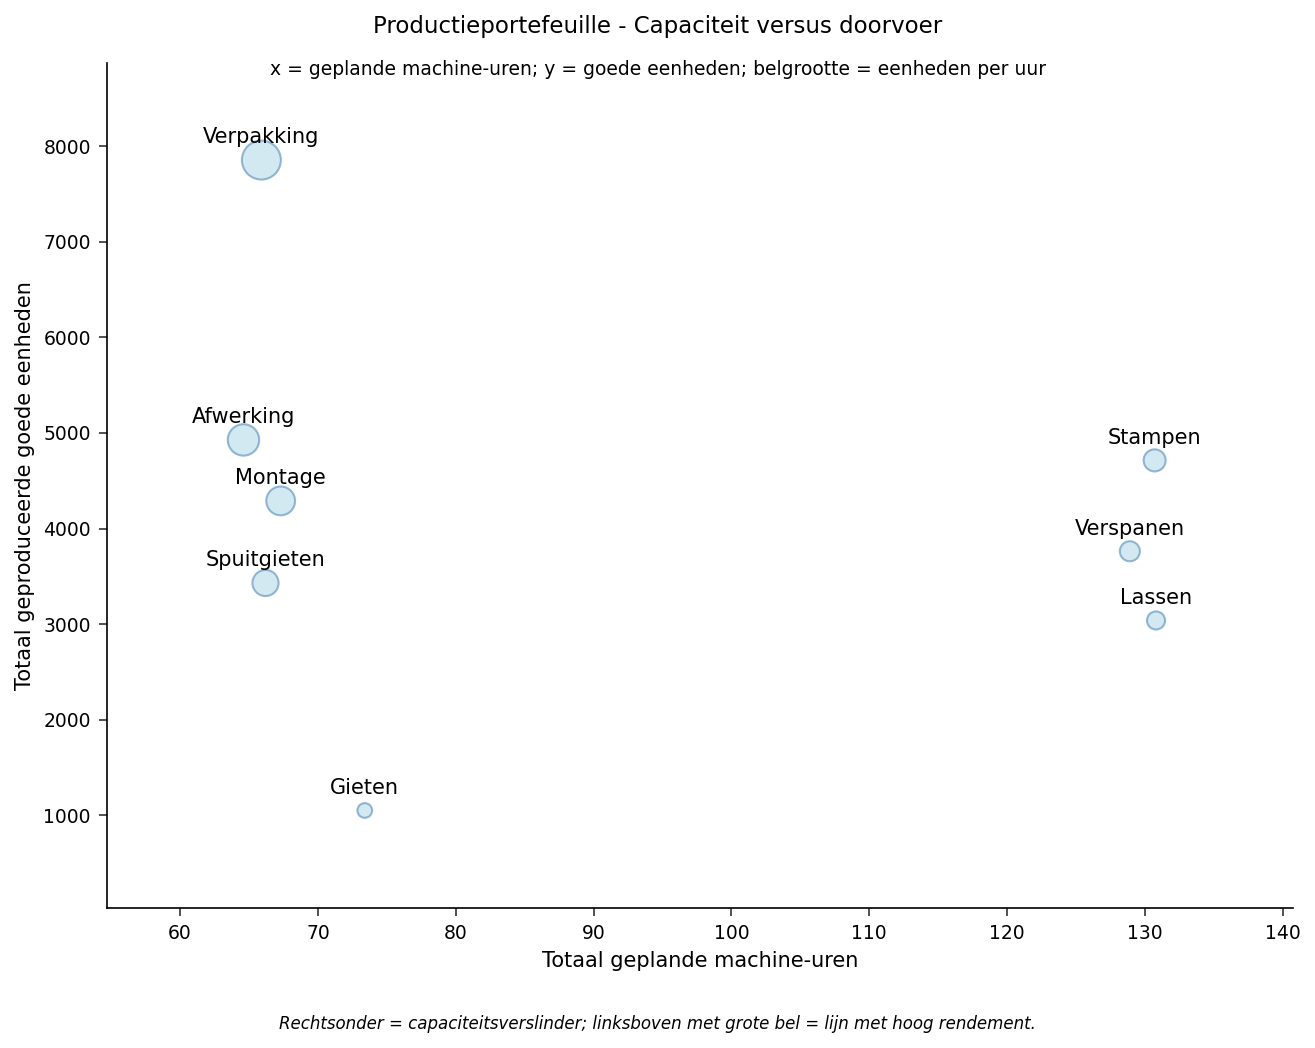

In [4]:
TITEL 'Productieportefeuille - Capaciteit versus doorvoer';
title2 'x = geplande machine-uren; y = goede eenheden; belgrootte = eenheden per uur';
footnote JUSTIFY=LEFT
    'Rechtsonder = capaciteitsverslinder; linksboven met grote bel = lijn met hoog rendement.';

PROCEDURE SGPLOT GEGEVENS=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS label='Totaal geplande machine-uren';
    YAXIS label='Totaal geproduceerde goede eenheden';
UITVOEREN;

TITEL; title2; footnote;


## 5. Doorvoer per lijn, uitgesplitst per fabriek

Om te zien hoe de output van elke lijn zich verdeelt over de drie fabrieken, stapelt een `VBAR product_line / response=good_units group=plant`-grafiek de bijdragen per fabriek binnen elke staaf. Dit is de segmentatieweergave: ze toont zowel de totale hoogte (goede eenheden per lijn) als de fabrieksmix binnen elke staaf, zodat je lijnen kunt herkennen waar één fabriek de output domineert.

                                Goede eenheden per productielijn, gestapeld per fabriek                                 
                         Staafhoogte = totaal goede eenheden; segmenten = bijdrage per fabriek                          




NOTE: Option TITLE changed to Goede eenheden per productielijn, gestapeld per fabriek.
NOTE: Option TITLE2 changed to Staafhoogte = totaal goede eenheden; segmenten = bijdrage per fabriek.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


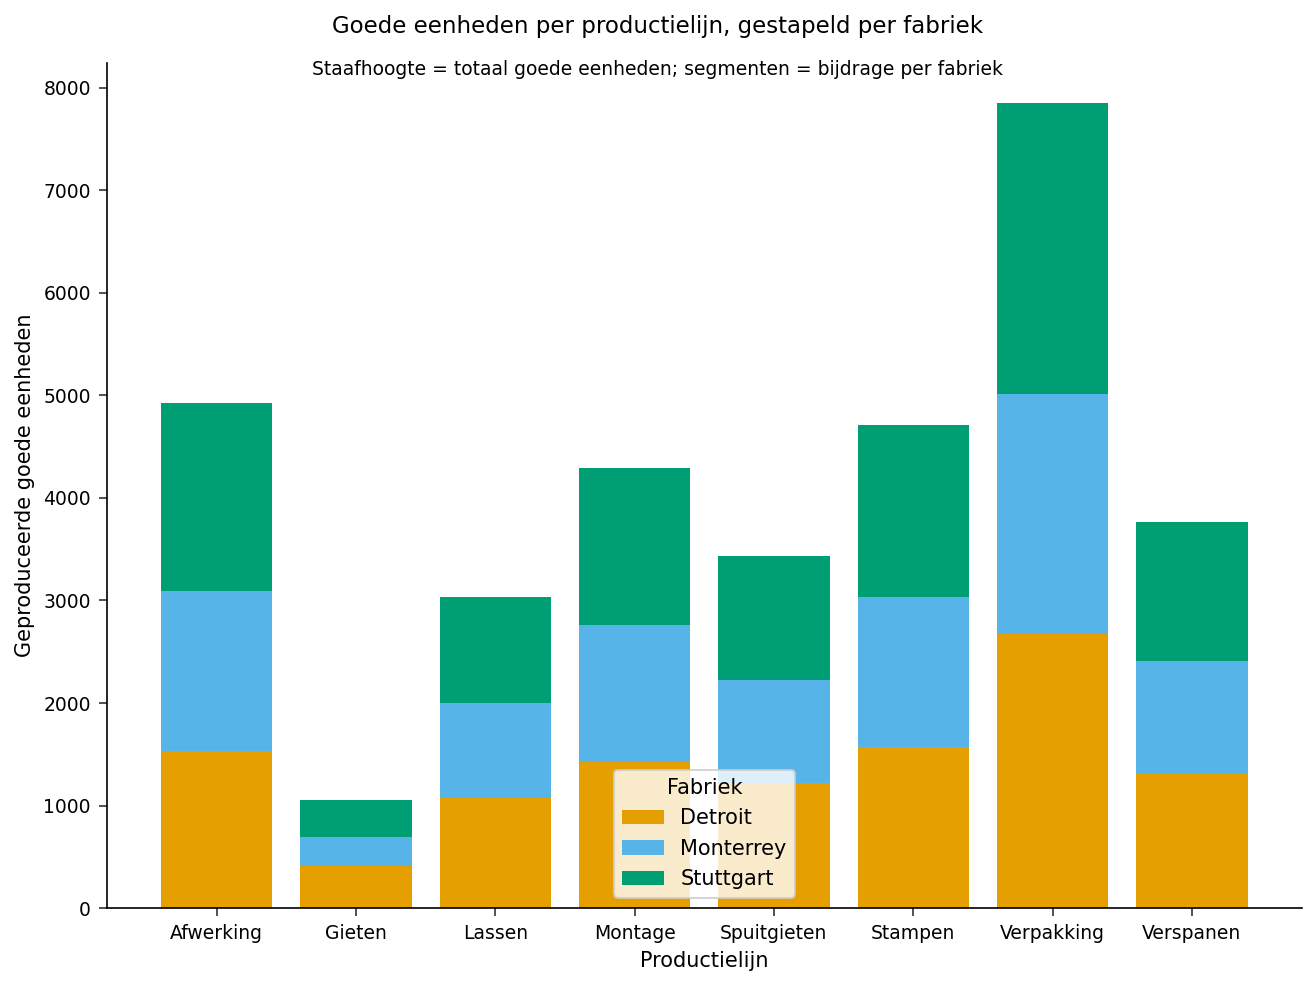

In [5]:
TITEL 'Goede eenheden per productielijn, gestapeld per fabriek';
title2 'Staafhoogte = totaal goede eenheden; segmenten = bijdrage per fabriek';

PROCEDURE SGPLOT GEGEVENS=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS label='Productielijn' fitpolicy=ROTATE;
    YAXIS label='Geproduceerde goede eenheden';
    keylegend / TITEL='Fabriek' position=bottom;
UITVOEREN;

TITEL; title2;


## 6. Analyse van productiviteit voor één fabriek (WHERE)

Horizontale staven (`HBAR`) zijn geschikt voor lange productielijn-labels. Een `WHERE`-clausule beperkt de data tot de fabriek Stuttgart, en de staven worden getekend voor `units_per_hr`, zodat de grafiek de lijnen van Stuttgart rangschikt naar productiviteit. Omdat de invoer oplopend gesorteerd is op percentage, staat de minst productieve lijn onderaan en de meest productieve bovenaan.

                              Fabriek Stuttgart - lijnen gerangschikt naar productiviteit                               


Staaflengte = goede eenheden per machine-uur (analyse van een fabriek).



NOTE: Option TITLE changed to Fabriek Stuttgart - lijnen gerangschikt naar productiviteit.
NOTE: Option FOOTNOTE changed to Staaflengte = goede eenheden per machine-uur (analyse van een fabriek)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


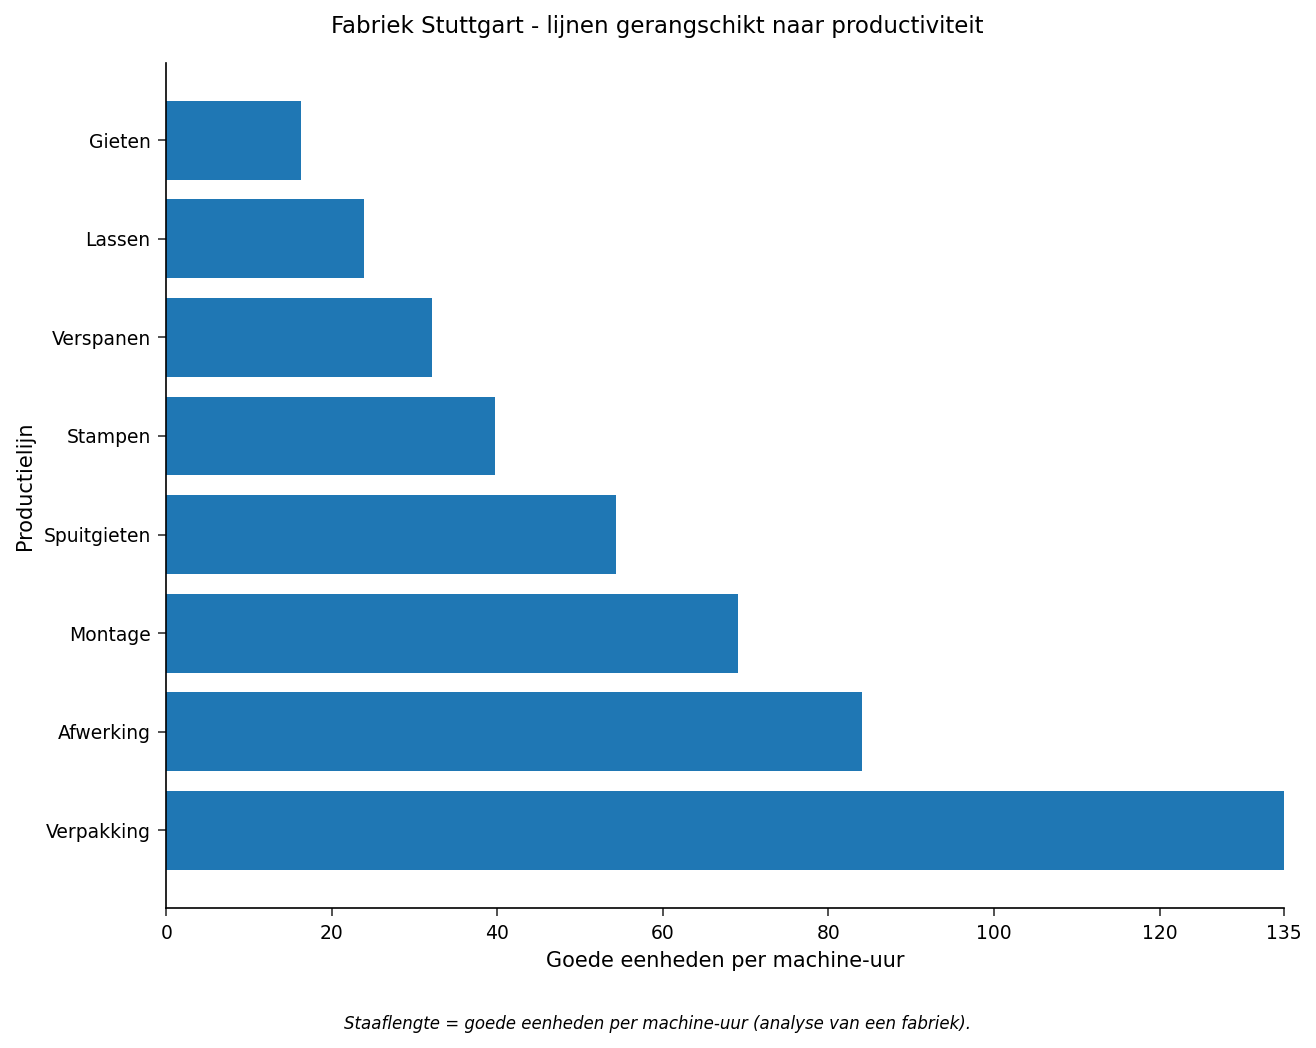

In [6]:
TITEL 'Fabriek Stuttgart - lijnen gerangschikt naar productiviteit';
footnote JUSTIFY=LEFT 'Staaflengte = goede eenheden per machine-uur (analyse van een fabriek).';

PROCEDURE SGPLOT GEGEVENS=work.line_capacity;
    WAAR plant = 'Stuttgart';
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS label='Goede eenheden per machine-uur';
    YAXIS label='Productielijn';
UITVOEREN;

TITEL; footnote;


## 7. Fabrieksvergelijking naast elkaar (geclusterde staven)

Om de drie fabrieken lijn voor lijn te vergelijken, tekent een geclusterde staafgrafiek (`GROUPDISPLAY=CLUSTER`) Detroit, Monterrey en Stuttgart als aangrenzende staven binnen elke productielijn. Dit is de appels-met-appels-fabrieksweergave: voor elke lijn kun je aflezen welke fabriek de meeste goede eenheden produceerde, waardoor de efficiëntieverschillen tussen fabrieken (Stuttgart hoogst, Monterrey laagst) direct zichtbaar worden.

                                   Goede eenheden per lijn en fabriek - naast elkaar                                    
                          Geclusterde staven: een staaf per fabriek binnen elke productielijn                           




NOTE: Option TITLE changed to Goede eenheden per lijn en fabriek - naast elkaar.
NOTE: Option TITLE2 changed to Geclusterde staven: een staaf per fabriek binnen elke productielijn.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


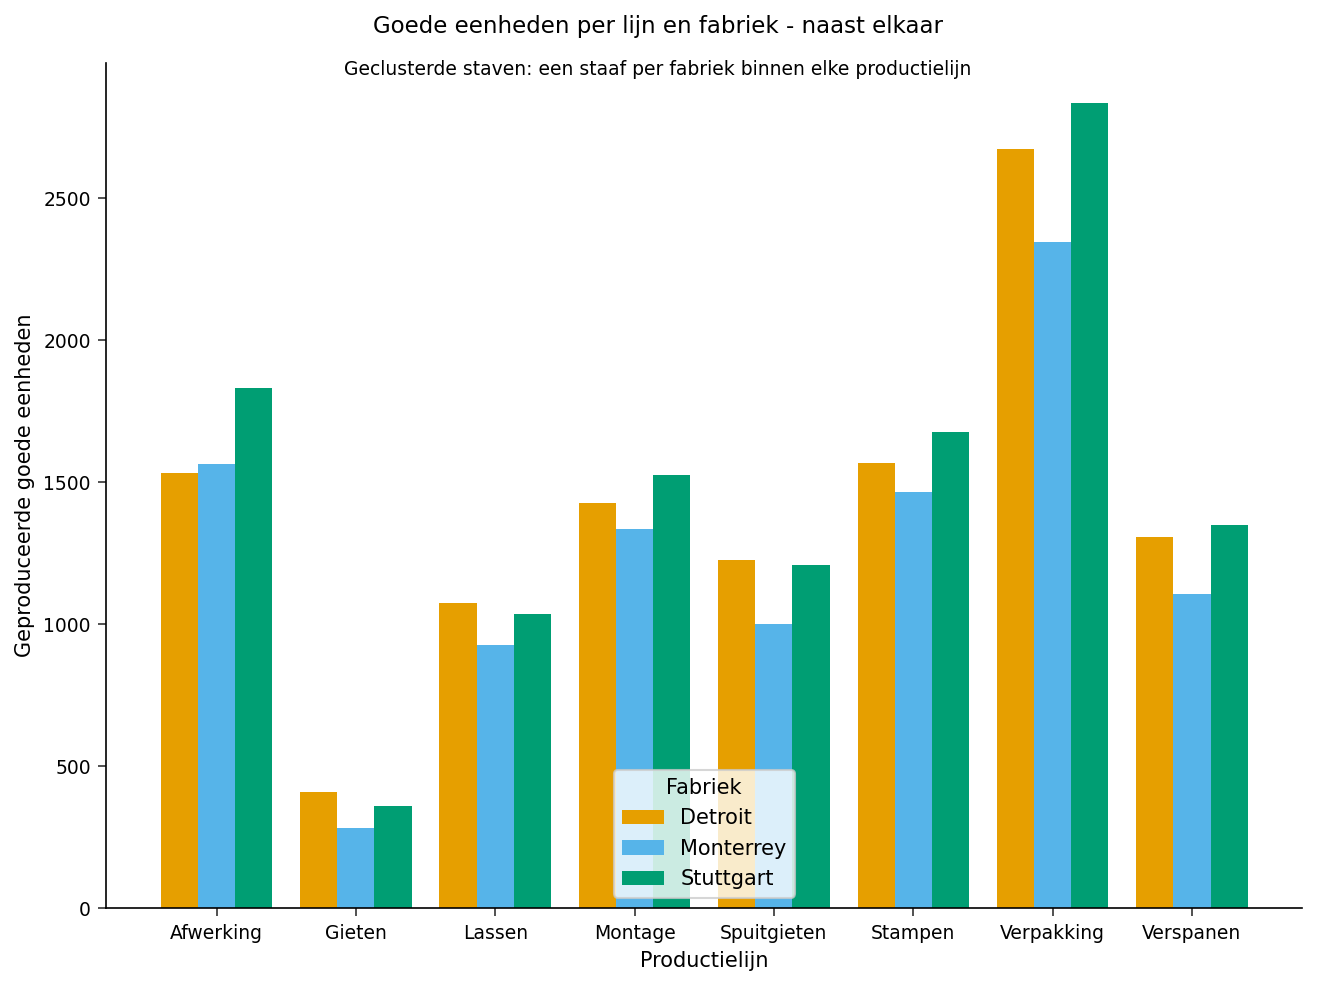

In [7]:
TITEL 'Goede eenheden per lijn en fabriek - naast elkaar';
title2 'Geclusterde staven: een staaf per fabriek binnen elke productielijn';

PROCEDURE SGPLOT GEGEVENS=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS label='Productielijn' fitpolicy=ROTATE;
    YAXIS label='Geproduceerde goede eenheden';
    keylegend / TITEL='Fabriek' position=bottom;
UITVOEREN;

TITEL; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;


## Interpretatie

Door capaciteit en doorvoer op dezelfde assen uit te zetten, komt een verband aan het licht dat een eendimensionale staafgrafiek zou verbergen. **Gieten** is de duidelijkste capaciteitsverslinder van de portefeuille: in de productiviteitsrangschikking staat het onderaan met **14,3 goede eenheden per machine-uur**, en in het bel-diagram valt het linksonder als kleine bel — het verbruikt **10,1%** van de totale geplande uren maar levert slechts **3,2%** van de goede eenheden op (het heeft ook het laagste rendement, ~91%, door zijn hoge afkeurpercentage). Het is de belangrijkste kandidaat voor cyclustijd- en afkeurreductie-kaizen. Aan het andere uiterste is **Verpakking** de opvallende lijn met hoog rendement, met **119,2 eenheden per machine-uur** — een grote bel hoog op de doorvoeras die **9,1%** van de capaciteit omzet in **23,8%** van alle goede eenheden; het beschermen van de beschikbaarheid ervan levert onevenredig veel output op. **Afwerking** (76,3 eenheden/uur) en **Montage** (63,7) volgen hetzelfde hoogrendementpatroon.

Het patroon is systematisch: de vier trage, capaciteitshongerige upstream-lijnen — Gieten, Lassen (23,2 eenheden/uur), Verspanen (29,2) en Stampen (36,1) — verbruiken samen ongeveer **64%** van de geplande uren maar leveren slechts ongeveer **38%** van de goede eenheden, terwijl de vier snelle downstream-lijnen meer opleveren dan de uren die ze verbruiken rechtvaardigen. De per-fabriek-gestapelde weergave en de naast-elkaar-geclusterde staven tonen de fabrieksdimensie hierachter: **Stuttgart** draait het heetst met **49,9 goede eenheden per machine-uur**, **Detroit** zit er middenin met **44,9**, en **Monterrey** blijft achter met **41,6** — consistent met de hogere gemodelleerde uitval van Monterrey. Operationeel wijst dit op het herverdelen van geplande uren naar de downstream-lijnen met hoog rendement en het benchmarken van de uitval van Monterrey tegen de aanpak van Stuttgart.

*Alleen synthetische data — de cijfers illustreren tweedimensionale capaciteit-versus-doorvoervisualisatie met PROC SGPLOT, geen werkelijke fabrieksprestaties.*